<center><h1>Typical Sample Analysis of Clusters with Self-Organizing Maps (SOM) and K-means</h1></center>

In the representativity module of the IntraSOM library we implement some metrics to:
1) Calculate the responsibility of SOM neurons to the clusters obtained with K-means according to a Cluster Membership Probability Function (CMPF), inspired by mixture models;
2) Infer the clusters weights using a probabilistic approach;
3) Select typical samples from clusters using the Silhouette Coefficient (SC).

To understand the CMPF, we illustrate how clustering is done by the IntraSOM clustering module (Figure 1).
<div style="text-align: center; padding: 0px;">
  <img src="images/som_kmeans_clustering.jpg" style="max-width: 400px;">
</div>
<div style="text-align: center; font-size: 90%;">
<strong>Figure 1 –</strong> <em>
Two-stage clustering with SOM and a centroid-based clustering method.  
(A) Dataset with two cluster structures. (B) First-stage clustering with SOM, forming proto-clusters of samples; red lines represent high dissimilarity boundaries.  
(C) Second-stage clustering with a centroid-based method, resulting in clusters of neurons.  
(D) Two final clusters of samples.
</em>
</div>

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Toy datasets
from sklearn import datasets

# Processing
import intrasom
from intrasom import SOMFactory
from intrasom.visualization import PlotFactory
from intrasom.clustering import ClusterFactory
from intrasom.representativity import ClusterRepresentativity

# Post processing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

c:\Users\gusta\InTRA\IntraSOM\intrasom-venv\Lib\site-packages\intrasom\visualization.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Load dataset
iris = datasets.load_iris(as_frame=True)
target_mapping = {
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
}

# Apply the mapping to the 'target' column
iris.frame['target'] = iris.frame['target'].map(target_mapping)
iris.frame.rename(columns={'target':'species'}, inplace=True)

iris.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Processing with SOM
mapsize = (10,6) # Vesanto's heuristic: 5*sqrt(150) ~ 60 neurons
som_iris = intrasom.SOMFactory.build(
    data = iris.data,
    mapsize = mapsize,
    mapshape = 'toroid',
    lattice = 'hexa',
    normalization = 'var',
    initialization = 'random',
    neighborhood = 'gaussian',
    training = 'batch',
    name = 'SOM_iris_dataset',
    component_names = iris.feature_names,
    unit_names = ['cm', 'cm', 'cm', 'cm'],
    missing = False)

Loading dataframe...
Normalizing data...
Creating neighborhood...
Initializing map...


Creating Neuron Distance Rows:   0%|          | 0/6 [00:00<?, ?rows/s]

Starting Training...
Rough Training:


  0%|          | 0/12 [00:00<?, ?it/s]

Fine Tuning:


  0%|          | 0/20 [00:00<?, ?it/s]

Saving...
Training Report Created
Training completed successfully.


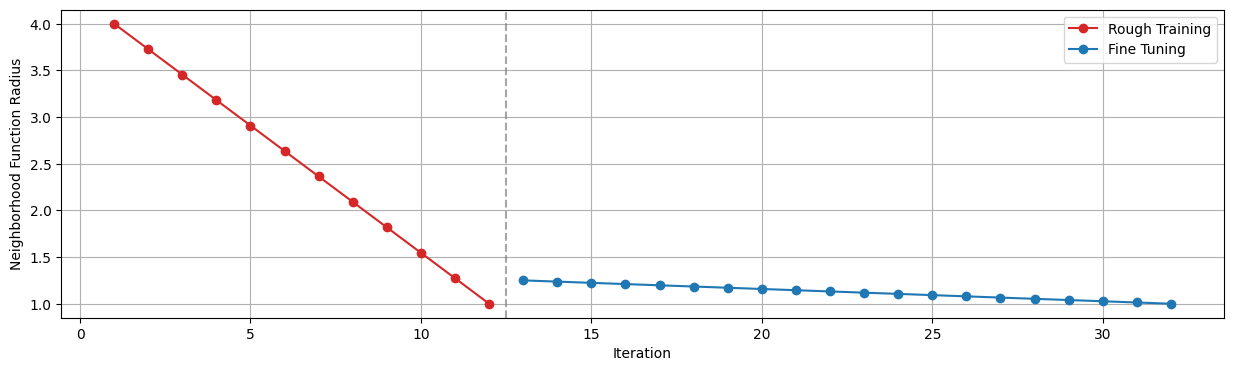

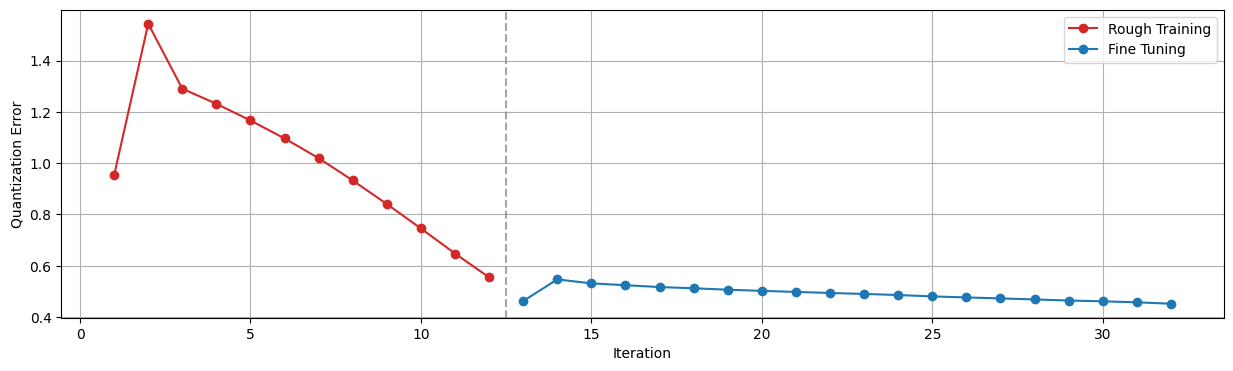

In [6]:
# Training of the SOM
som_iris.train(qe_plot=True, radius_plot=True, plot_figsize=(15,4))

In [77]:
# View neurons dataframe
som_iris.results_dataframe

,BMU,q-error,Udist,Ret_x,Ret_y,Cub_x,Cub_y,Cub_z,B_sepal length (cm),B_sepal width (cm),B_petal length (cm),B_petal width (cm)
0,2,0.218621,0.037523,1,0,1,-1,0,5.100136,3.582323,1.510734,0.273534
1,21,0.271989,0.159149,0,2,-1,-1,2,4.824007,3.077829,1.638631,0.286404
2,22,0.298934,0.008550,1,2,0,-2,2,4.890713,3.210015,1.559537,0.263007
3,21,0.318474,0.159149,0,2,-1,-1,2,4.824007,3.077829,1.638631,0.286404
4,2,0.176425,0.037523,1,0,1,-1,0,5.100136,3.582323,1.510734,0.273534
...,...,...,...,...,...,...,...,...,...,...,...,...
145,46,0.443996,0.113754,5,4,3,-7,4,6.823956,3.028788,5.685274,2.079838
146,37,0.503137,0.143243,6,3,5,-8,3,6.240280,2.651295,4.972378,1.633281
147,56,0.122376,0.114125,5,5,3,-8,5,6.452542,2.999281,5.373094,2.043868
148,5,0.632170,0.120327,4,0,4,-4,0,6.508625,3.227423,5.299342,2.054920


In [25]:
np.unique_counts(som_iris.results_dataframe['BMU'].values)

UniqueCountsResult(values=array([ 1,  2,  4,  5,  7,  8,  9, 11, 12, 14, 15, 17, 18, 19, 21, 22, 24,
       25, 26, 27, 28, 29, 32, 34, 35, 36, 37, 38, 39, 40, 42, 44, 45, 46,
       47, 48, 49, 50, 51, 52, 55, 56, 57, 59]), counts=array([ 2,  7,  1,  4,  4,  2,  7,  4,  3,  1,  2,  4,  1,  1, 11,  5,  4,
        2,  1,  4,  1,  4,  3,  1,  7,  1,  4,  4,  5,  1,  1,  1,  3,  3,
        4,  4,  4,  2,  1, 12,  7,  2,  3,  2]))

In [99]:
labels = np.unique(iris.frame["species"].values) # user defined
# Generate an empty pandas dataframe with number of rows equal to the number of samples and columns equal to the number of labels
species_df = pd.DataFrame(0, index=np.arange(1,len(som_iris.neurons_dataframe)+1), columns=labels)
species_df.loc[1,'setosa']+=1

for s, bmu in zip(iris.frame["species"].values, som_iris.results_dataframe['BMU'].values):
    species_df.loc[bmu, s] += 1 # compute the votes for each neuron

# Drop neurons without hits and get the most representative species for each neuron
species_df = species_df[(species_df.T != 0).any()]
# species_df.idxmax(axis=1) # most represented species for each neuron

# Now iterate through the species_df.idxmax(axis=1) series and get the values for the BMU (index of the series) in the som_iris.neurons_dataframe
representative_neurons = [] # list to store the representative neurons
for neuron in species_df.idxmax(axis=1).index:
    representative_neurons.append(som_iris.neurons_dataframe.iloc[neuron,7:].values)
representative_neurons = np.array(representative_neurons)
# species_df.idxmax(axis=1)
representative_neurons

oversamples = pd.DataFrame(representative_neurons, columns=iris.feature_names)
oversamples['species'] = species_df.idxmax(axis=1).values
oversamples

# np.unique_counts(species_df.idxmax(axis=1)) # number of neurons representing each label

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.100136,3.582323,1.510734,0.273534,setosa
1,5.326960,3.630882,1.875717,0.432920,setosa
2,6.508625,3.227423,5.299342,2.054920,versicolor
3,6.450129,3.118226,5.322805,2.028035,virginica
4,5.913118,2.885287,4.551196,1.549422,virginica
5,5.671640,2.869108,4.187606,1.360755,versicolor
6,5.337486,3.004316,3.182268,0.952775,versicolor
7,5.028832,3.403061,1.611453,0.294768,setosa
8,5.736387,3.370848,2.978394,0.866136,setosa
9,6.581588,3.093923,5.294586,1.862113,versicolor


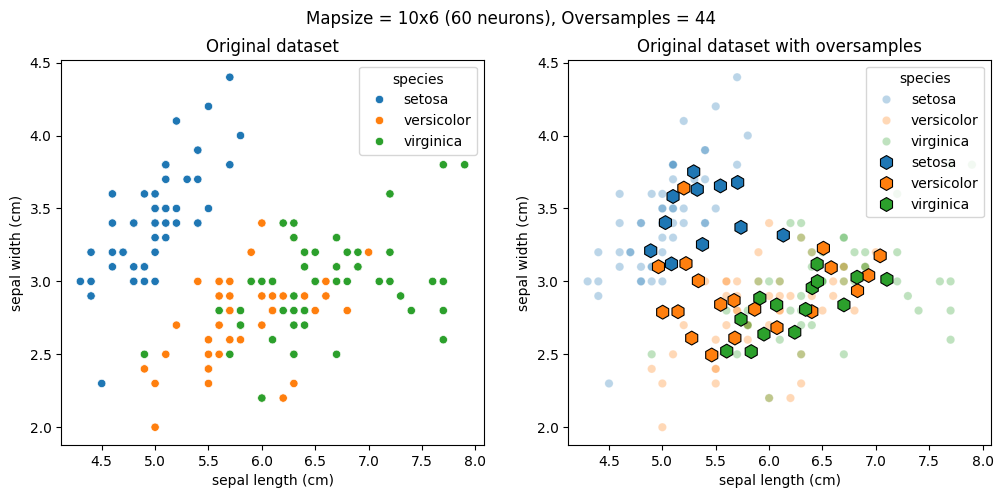

In [117]:
# Plot the original dataset and the original dataset with the oversamples
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.scatterplot(data=iris.frame, x='sepal length (cm)', y='sepal width (cm)', hue='species', ax=ax[0])
sns.scatterplot(data=iris.frame, x='sepal length (cm)', y='sepal width (cm)', hue='species', ax=ax[1], alpha=0.3)
sns.scatterplot(data=oversamples, x='sepal length (cm)', y='sepal width (cm)', hue='species', ax=ax[1], s=100, edgecolor='k', marker='h')
ax[0].set_title('Original dataset')
ax[1].set_title('Original dataset with oversamples')
plt.suptitle(f'Mapsize = {mapsize[0]}x{mapsize[1]} ({mapsize[0]*mapsize[1]} neurons), Oversamples = {len(oversamples)}')
plt.show()

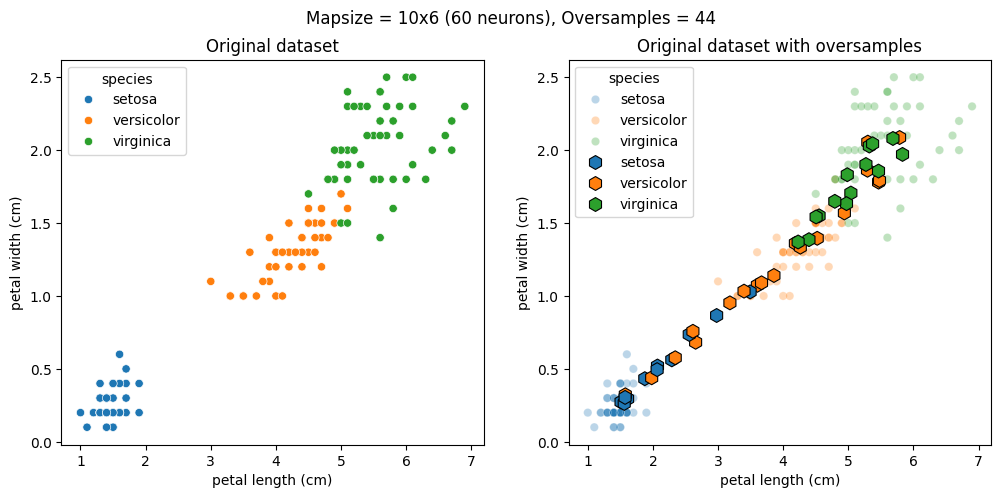

In [118]:
# Plot the original dataset and the original dataset with the oversamples
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.scatterplot(data=iris.frame, x='petal length (cm)', y='petal width (cm)', hue='species', ax=ax[0])
sns.scatterplot(data=iris.frame, x='petal length (cm)', y='petal width (cm)', hue='species', ax=ax[1], alpha=0.3)
sns.scatterplot(data=oversamples, x='petal length (cm)', y='petal width (cm)', hue='species', ax=ax[1], s=100, edgecolor='k', marker='h')
ax[0].set_title('Original dataset')
ax[1].set_title('Original dataset with oversamples')
plt.suptitle(f'Mapsize = {mapsize[0]}x{mapsize[1]} ({mapsize[0]*mapsize[1]} neurons), Oversamples = {len(oversamples)}')
plt.show()

Text(0.5, 1.0, 'PCA projection of the original Iris dataset (circles) and the oversamples (crosses)\nMapsize = 10x6 (60 neurons), Oversamples = 44')

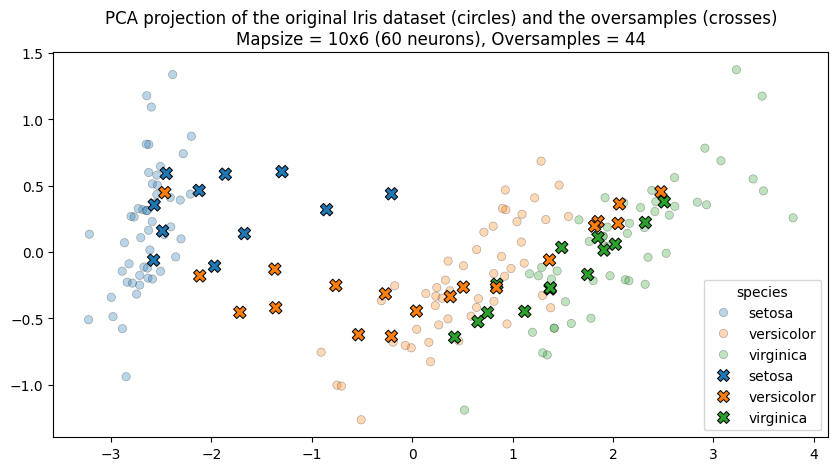

In [128]:
# Project the original dataset and the oversamples into the PCA space
pca = PCA(n_components=2)
pca_iris = pca.fit_transform(iris.data)
pca_oversamples = pca.transform(oversamples[iris.feature_names])
# Now plot the PCA projections
plt.figure(figsize=(10,5))
sns.scatterplot(x=pca_iris[:,0], y=pca_iris[:,1], hue=iris.frame['species'], alpha=0.3, edgecolor='k')
sns.scatterplot(x=pca_oversamples[:,0], y=pca_oversamples[:,1], hue=oversamples['species'], edgecolor='k', s=80, marker='X')
plt.title(f'PCA projection of the original Iris dataset (circles) and the oversamples (crosses)\nMapsize = {mapsize[0]}x{mapsize[1]} ({mapsize[0]*mapsize[1]} neurons), Oversamples = {len(oversamples)}')

In [ ]:
som_iris.results_dataframe['BMU'].values # best matching unit for each sample

array([ 2, 21, 22, 21,  2, 52, 11, 12, 21, 21, 52, 11, 21, 21, 52, 52, 52,
        2, 52, 52, 32, 51,  2, 32, 11, 21,  1,  2, 12, 22, 21, 32, 52, 52,
       21, 22, 42,  2, 21, 12,  2, 40, 22,  1, 52, 21, 52, 22, 52, 11, 44,
       24, 25, 49, 27,  9, 14, 50, 27, 59, 39,  8, 38, 17, 19, 24,  9, 29,
       38, 39,  7, 18, 37, 28, 17, 24, 27, 26,  8, 29, 39, 39, 29, 48,  9,
        4, 24, 38,  9, 49, 49, 17, 29, 39, 59,  9,  9, 17, 50,  9, 55, 48,
       35, 47, 56, 35, 49, 35, 36, 45,  5, 47, 46, 48, 57,  5, 15, 45, 35,
       38, 55, 57, 35, 37, 55, 34, 57,  7, 47, 25, 35, 45, 47, 27, 37, 35,
        5, 15,  7, 46, 55, 55, 48, 55, 55, 46, 37, 56,  5,  7])

In [ ]:
iris.frame["species"].values # user defined

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [17]:
som_iris.neurons_dataframe

,BMU,Udist,Ret_x,Ret_y,Cub_x,Cub_y,Cub_z,B_sepal length (cm),B_sepal width (cm),B_petal length (cm),B_petal width (cm)
1,1,0.344557,0,0,0,0,0,5.033801,3.391814,1.764344,0.389159
2,2,0.037523,1,0,1,-1,0,5.100136,3.582323,1.510734,0.273534
3,3,0.483217,2,0,2,-2,0,5.326960,3.630882,1.875717,0.432920
4,4,0.893681,3,0,3,-3,0,6.089554,3.416861,4.021821,1.427260
5,5,0.120327,4,0,4,-4,0,6.508625,3.227423,5.299342,2.054920
6,6,0.012601,5,0,5,-5,0,6.450129,3.118226,5.322805,2.028035
7,7,0.064730,6,0,6,-6,0,6.144498,2.962253,4.908075,1.773195
8,8,0.011314,7,0,7,-7,0,5.913118,2.885287,4.551196,1.549422
9,9,0.098414,8,0,8,-8,0,5.671640,2.869108,4.187606,1.360755
10,10,0.487875,9,0,9,-9,0,5.337486,3.004316,3.182268,0.952775


In [7]:
# Visualization module
plot_iris = PlotFactory(som_iris)

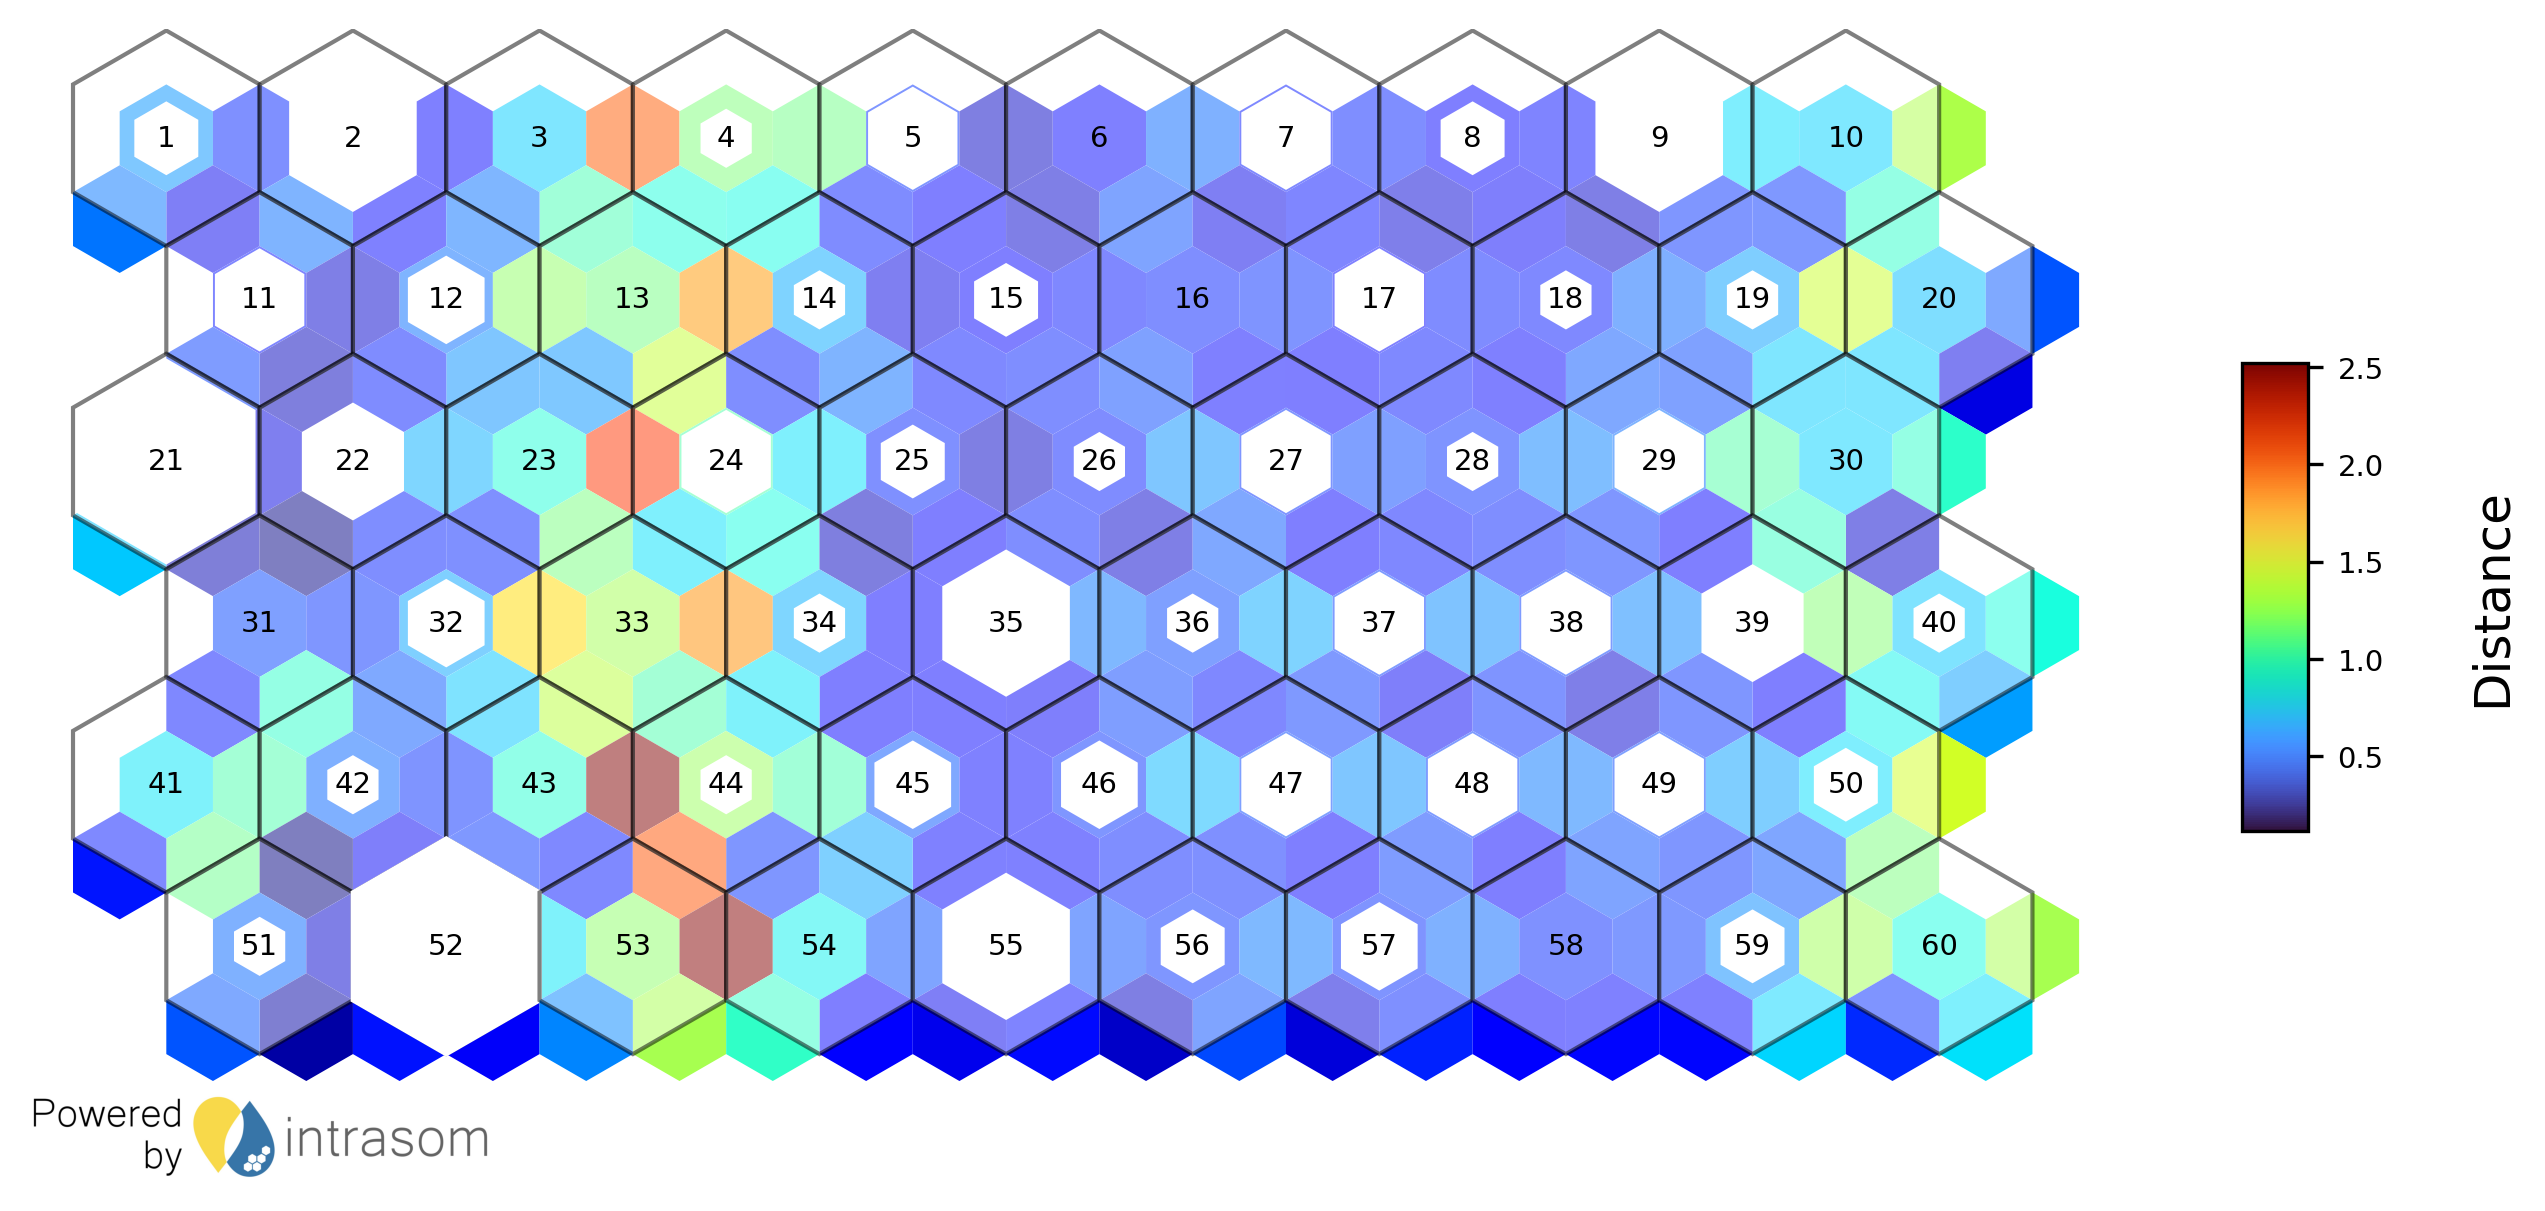

In [8]:
# U-matrix visualization: SOM space
plot_iris.plot_umatrix(
    figsize = (10,5),
    hits = True, # hits as white hexagons
    title = "",
    title_pad = 25,
    legend_title_size = 12,
    legend_ticks_size = 7,
    label_title_xy = (0,0.5),
    save = False,
    watermark_neurons=True, # template with the number of each neuron
    neurons_fontsize = 7)

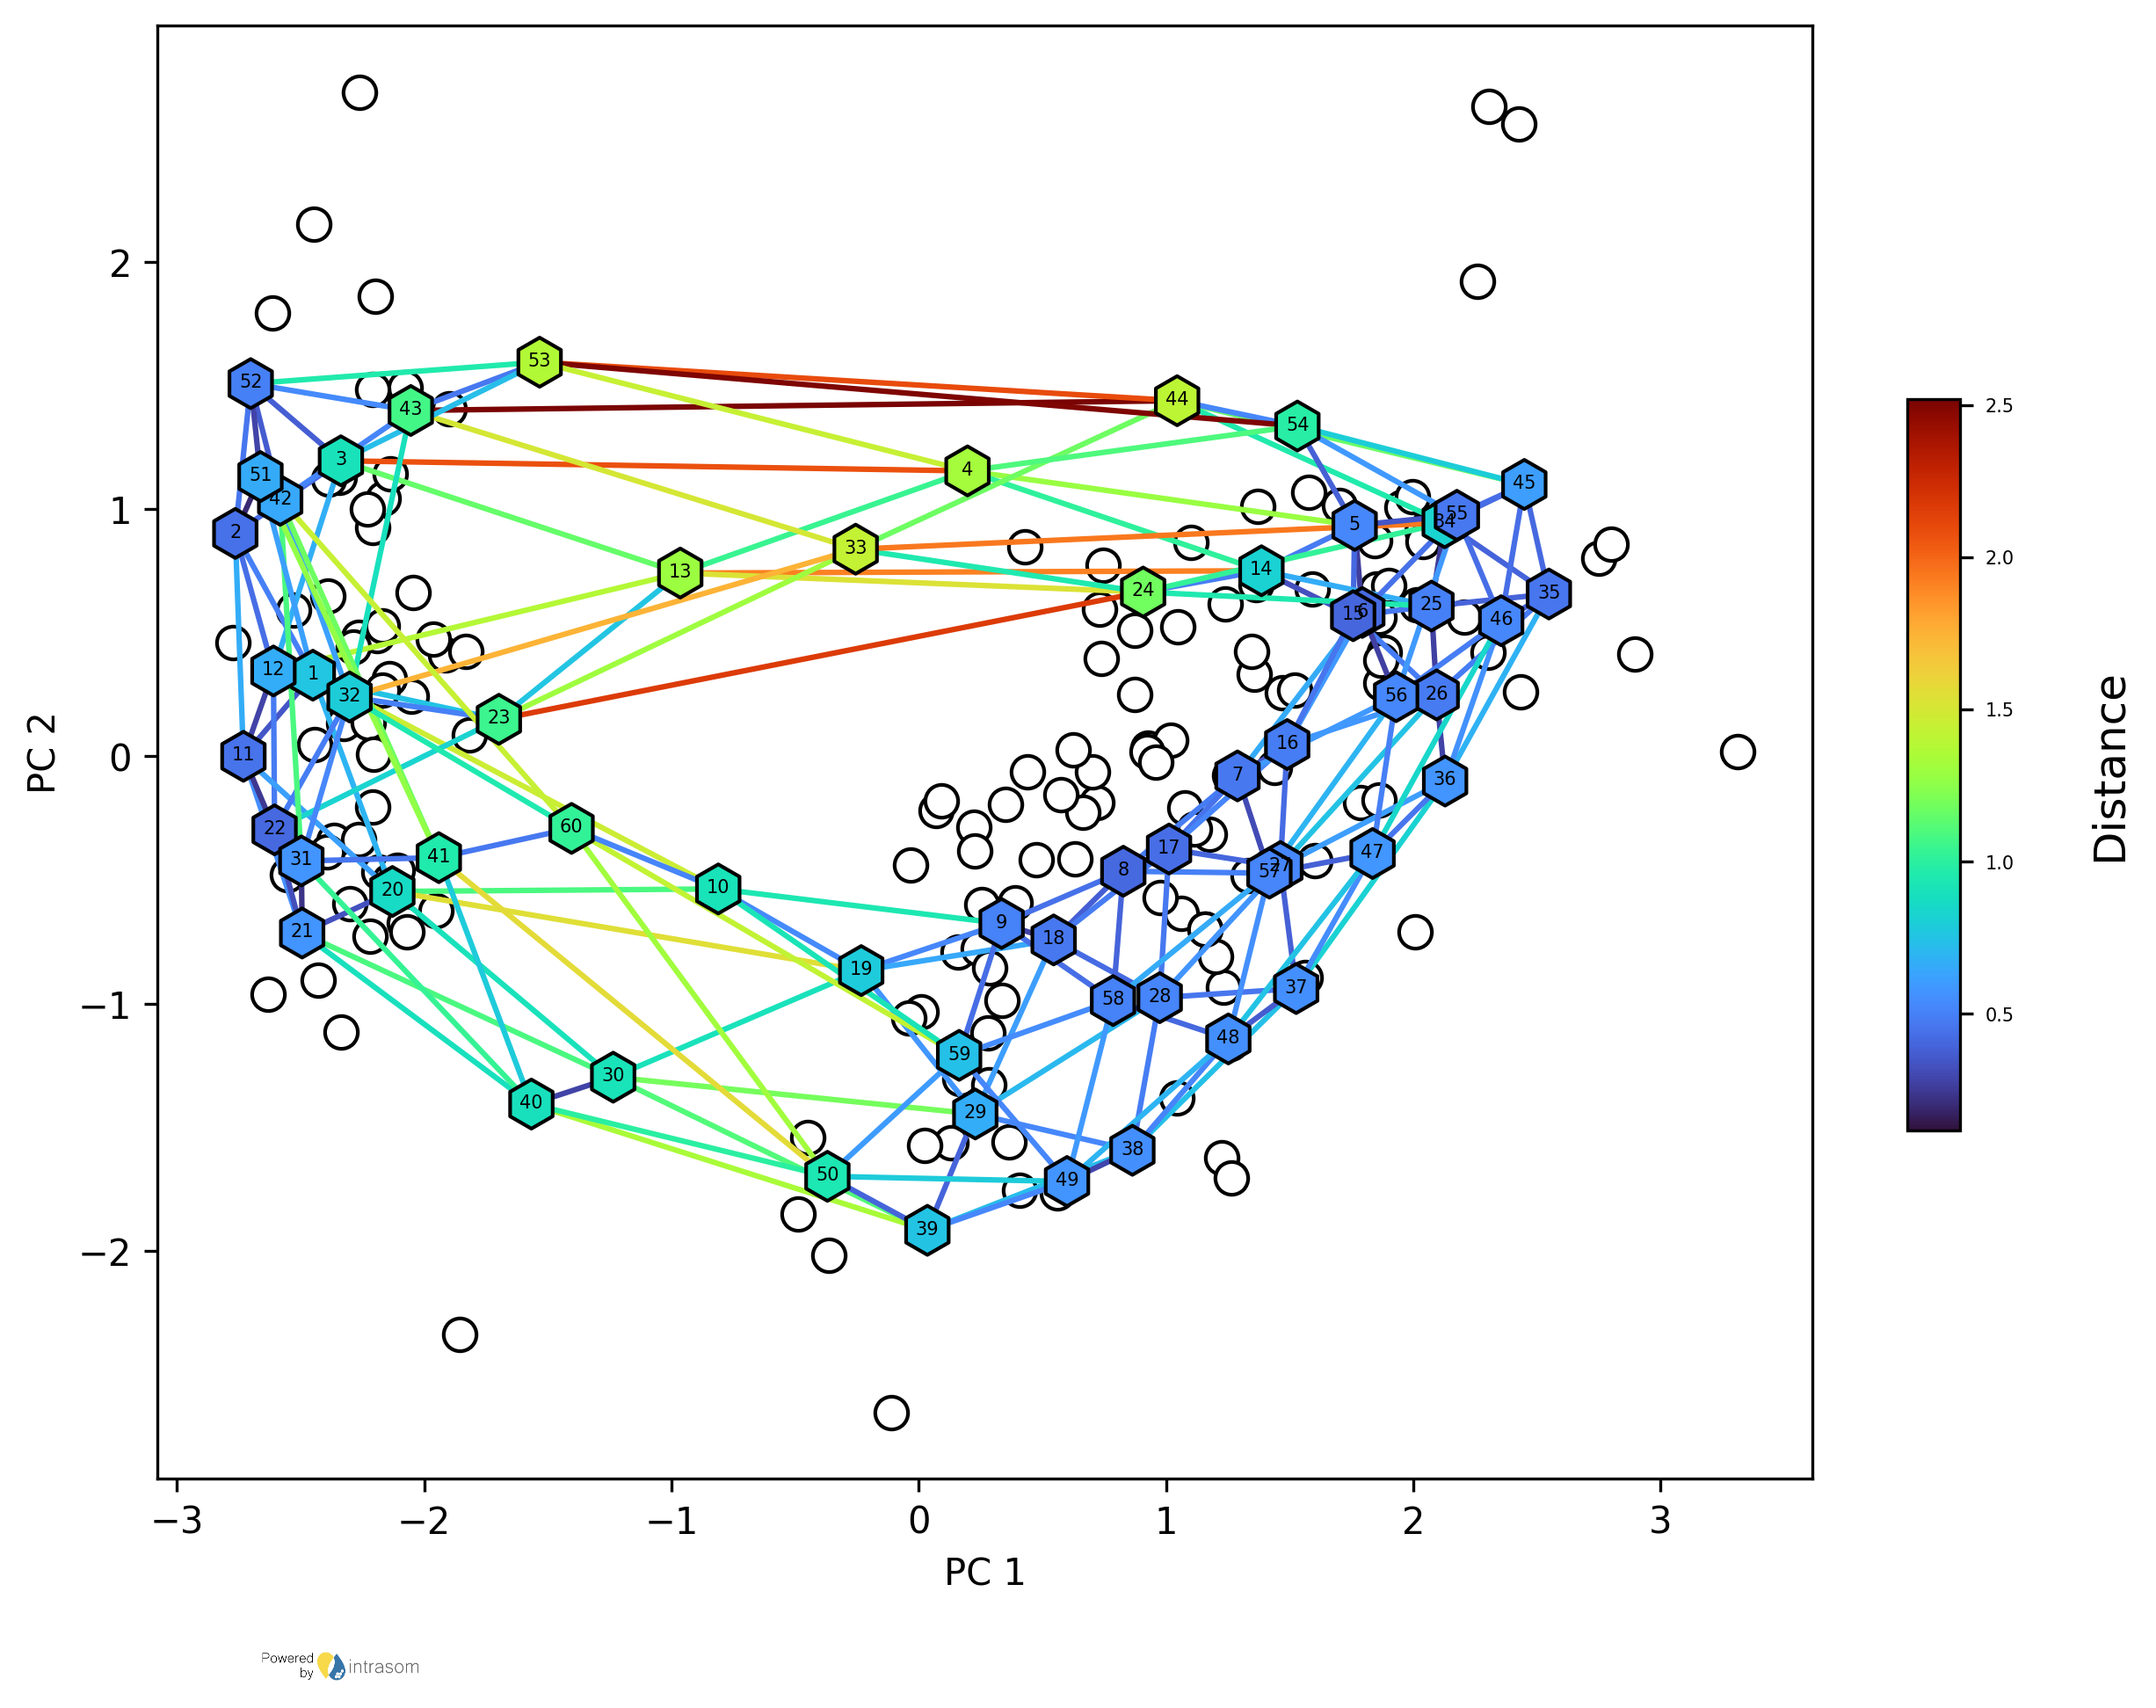

In [9]:
# U-matrix visualization: PCA space
plot_iris.plot_som_pca(
    figsize=(9,9),
    normalization='var', # the same as before
    title="",
    legend_title_size = 12,
    show_samples = True,
    samples_size = 80, # white circles
    show_connections = True, # lines connecting neighboring neurons
    connections_linewidth = 1.5,
    show_neurons = True,
    neurons_size = 180, # hexagons
    watermark_neurons = True # neurons template
)

In [8]:
# Clustering module
clustering_iris = ClusterFactory(som_iris)
clusters_iris = clustering_iris.kmeans(k=3) # k = 3, since we know the iris species are setosa, versicolor and virginica

In [9]:
# Visualize the BMU of each sample and its corresponding cluster
clustering_iris.results_cluster(clusters_iris)

,BMU,Udist,Ret_x,Ret_y,Cub_x,Cub_y,Cub_z,B_sepal length (cm),B_sepal width (cm),B_petal length (cm),B_petal width (cm),3_clusters
0,26,0.057197,5,2,4,-6,2,5.117313,3.574564,1.522404,0.278612,3
1,7,0.119529,6,0,6,-6,0,4.786123,3.101809,1.580841,0.268424,3
2,7,0.119529,6,0,6,-6,0,4.786123,3.101809,1.580841,0.268424,3
3,7,0.119529,6,0,6,-6,0,4.786123,3.101809,1.580841,0.268424,3
4,26,0.057197,5,2,4,-6,2,5.117313,3.574564,1.522404,0.278612,3
...,...,...,...,...,...,...,...,...,...,...,...,...
145,2,0.131041,1,0,1,-1,0,6.737075,2.943227,5.627077,2.067965,1
146,60,0.216147,9,5,7,-12,5,6.178637,2.611870,4.915185,1.634545,2
147,12,0.067977,1,1,1,-2,1,6.599654,3.062248,5.389835,2.022213,1
148,4,0.582565,3,0,3,-3,0,6.661516,3.286167,5.430817,2.099059,1


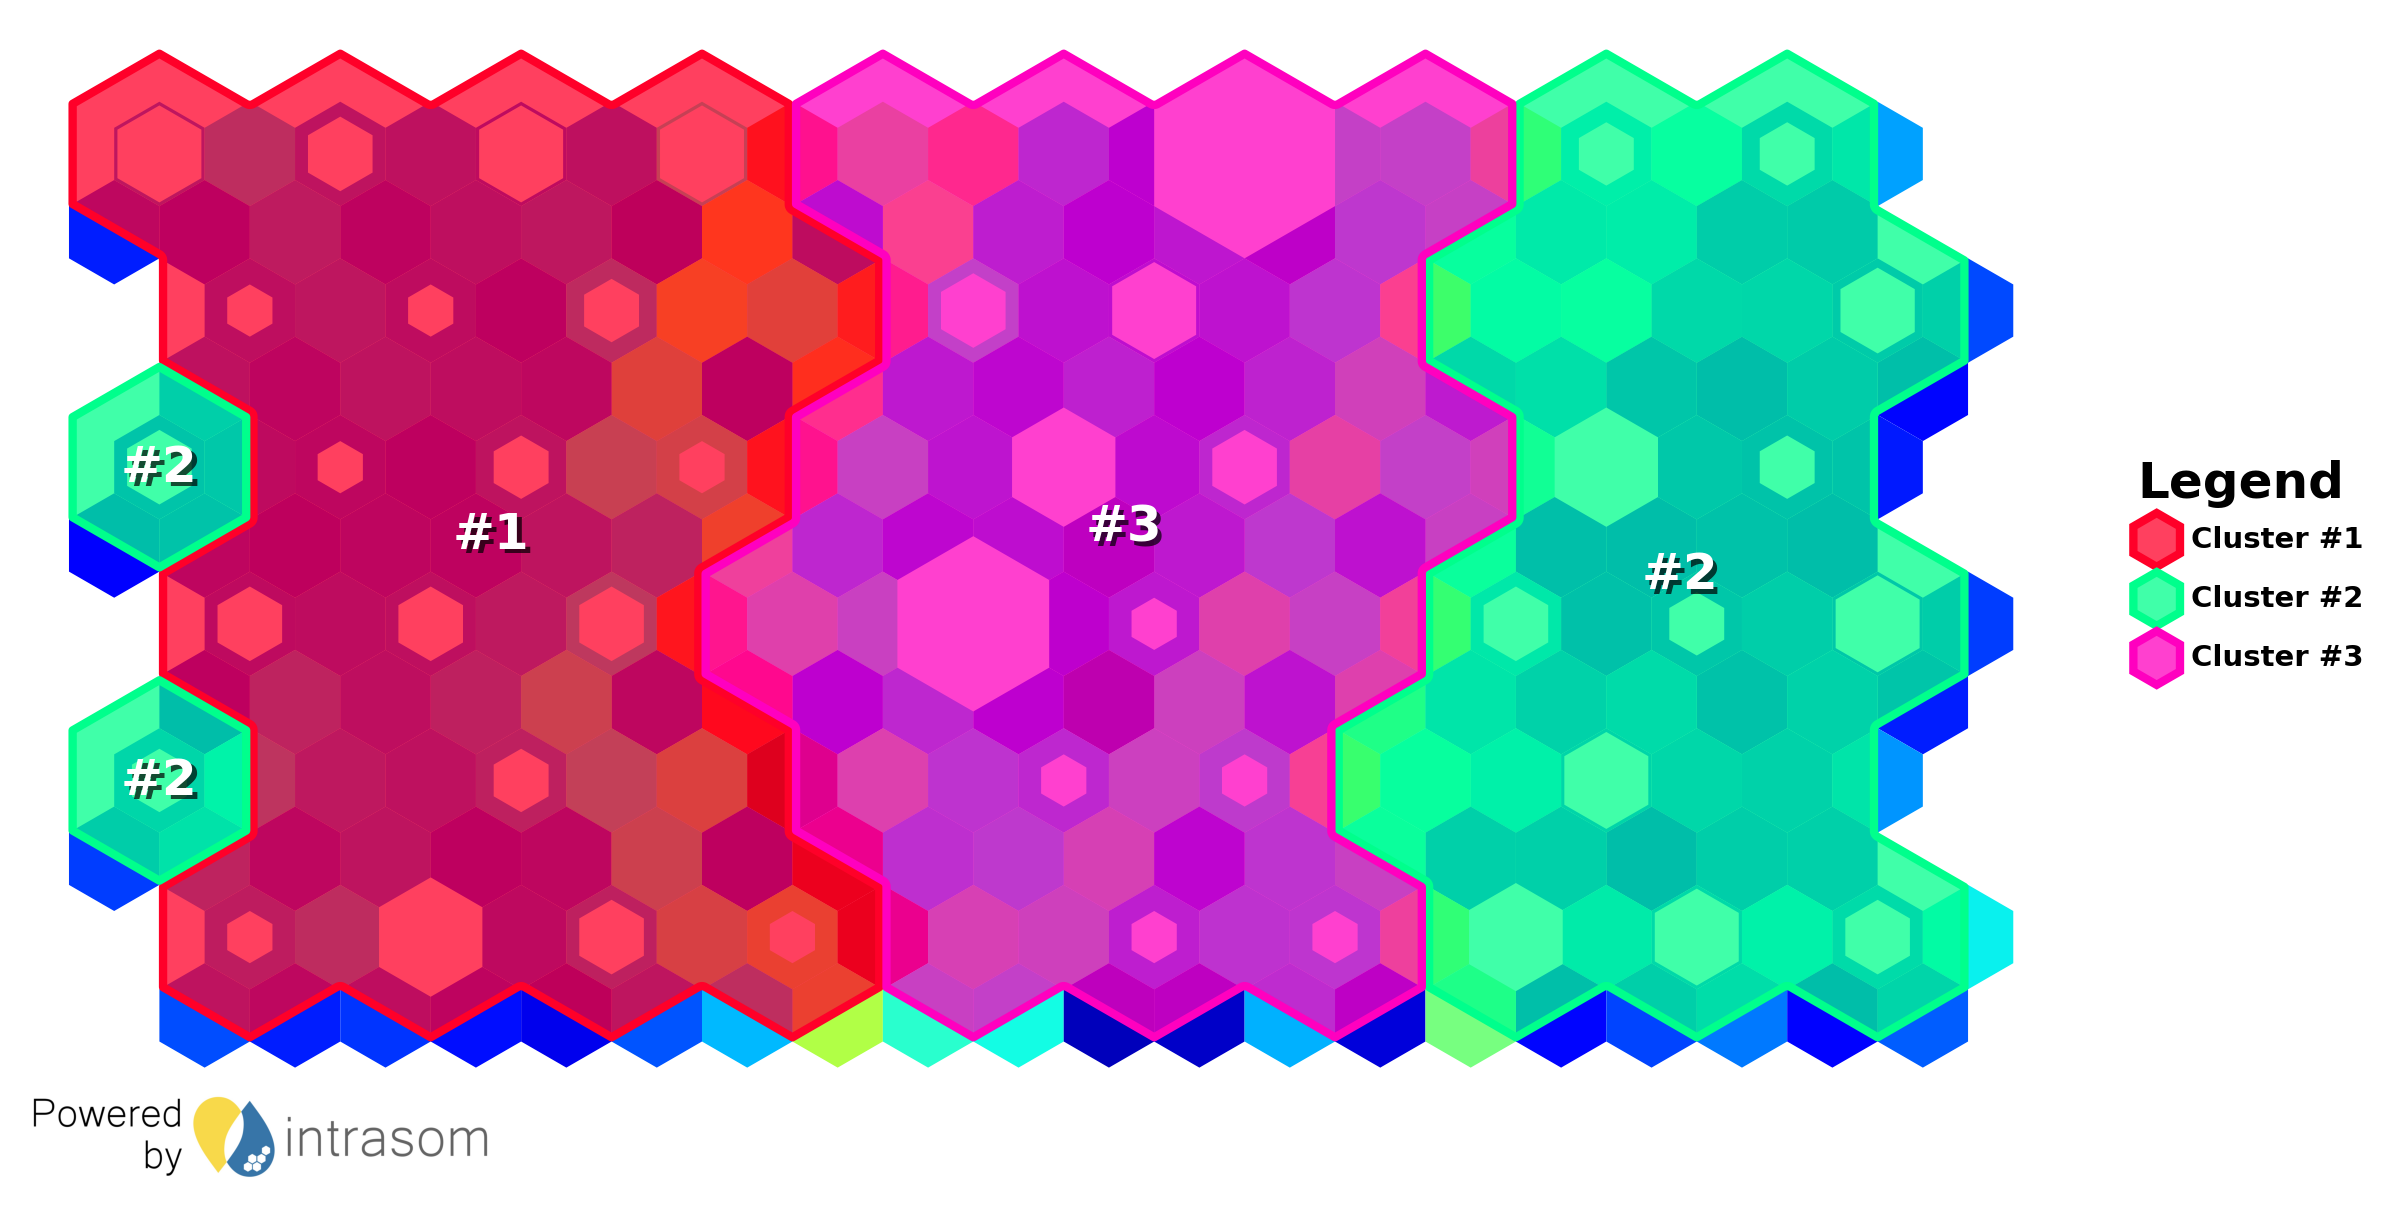

In [35]:
# Visualization of the clustered self-organized map
clustering_iris.plot_kmeans(
    figsize = (10,5),
    title = "",
    clusters = clusters_iris,
    title_size = 18,
    title_pad = 20,
    umatrix = True,
    colormap = "gist_rainbow",
    alfa_clust = 0.75,
    hits = True,
    legend_text_size = 7,
    cluster_outline = True,
    plot_labels = True)

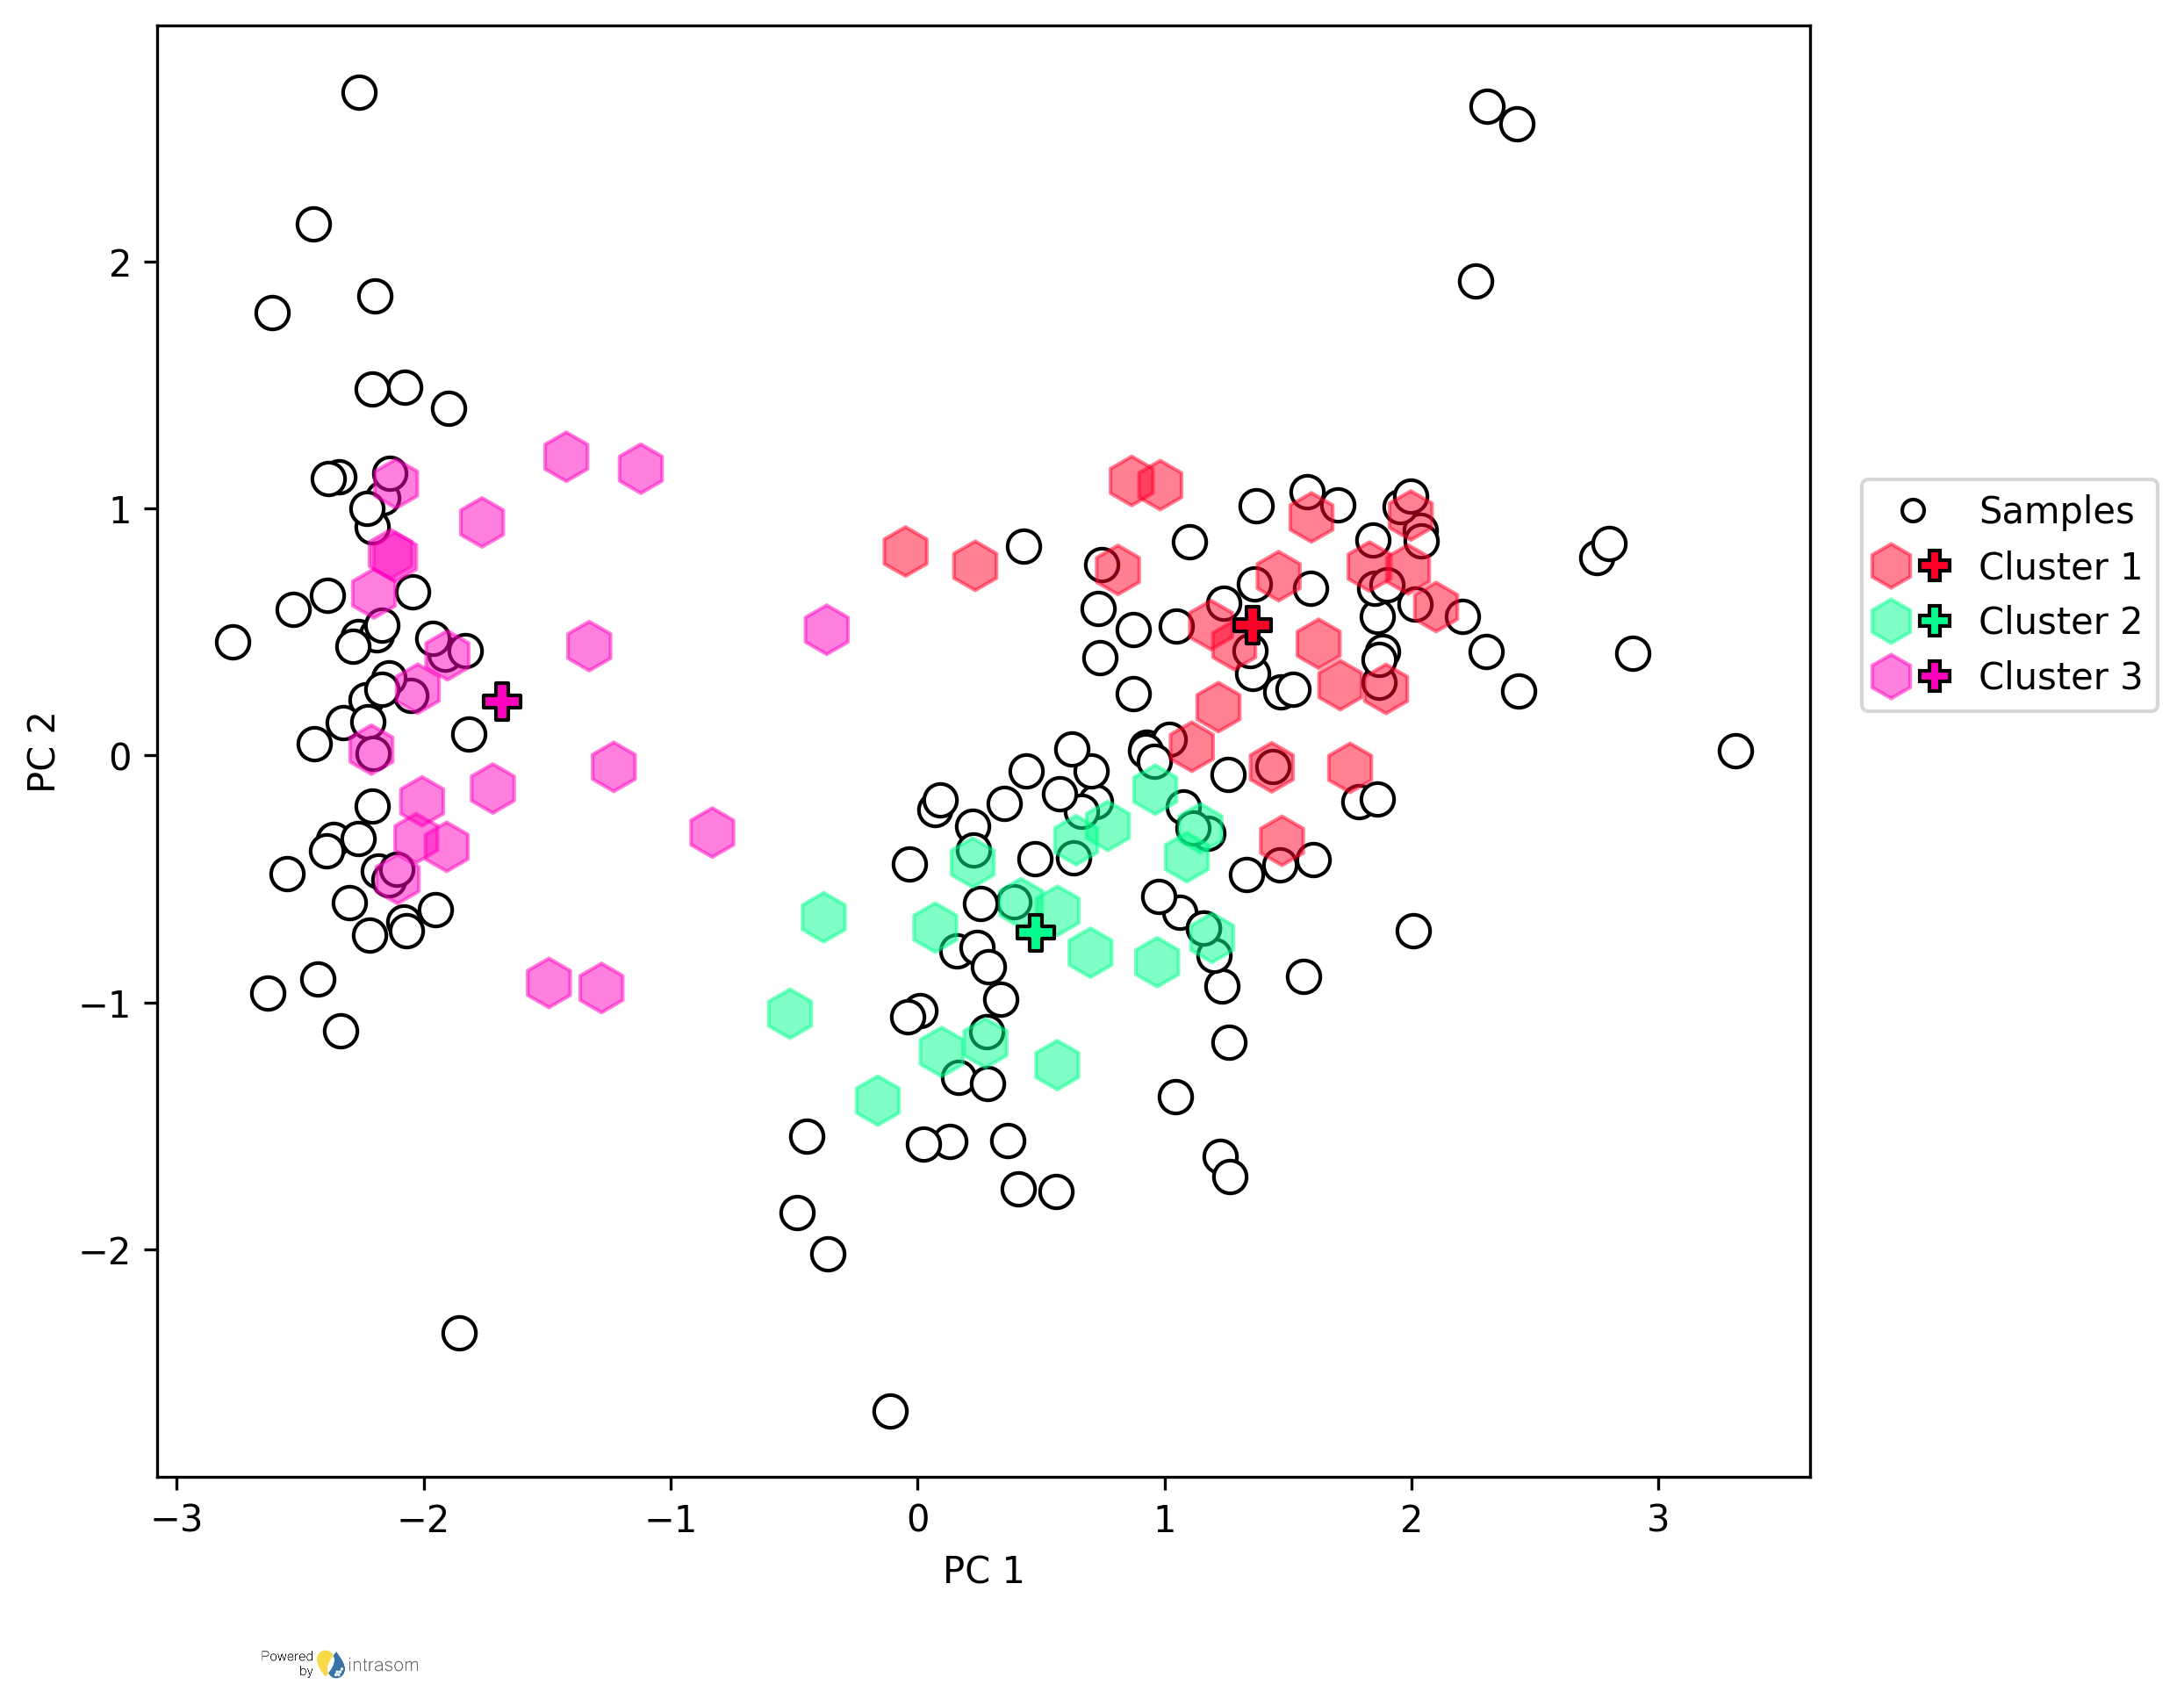

In [18]:
# Clusters of neurons in the PCA projection
clustering_iris.plot_clusters_pca(
    figsize = (9,9),
    normalization = 'var',
    title = '',
    show_samples = True,
    samples_size = 80,
    show_neurons=True,
    neurons_size = 180,
    show_centroids = True,
    centroids_size = 100,
    colormap='gist_rainbow',
    watermark_neurons=False,
    watermark_neurons_fontsize=5)

In [30]:
# Load cluster representativity module
representatives_iris = ClusterRepresentativity(clustering_iris)

# CMPF matrix, clusters weights and typical neurons of each cluster
neurons_responsibilities = representatives_iris.calculate_neurons_cmpf() # (n_neurons, n_clusters)
iris_clusters_weights = representatives_iris.clusters_weights
iris_typical_neurons = representatives_iris.cluster_representatives_indices
print(f'Weights of the clusters 1, 2 and 3, respectively: {iris_clusters_weights}')
print(f'Indices of the typical neurons of clusters 1, 2 and 3, respectively: {iris_typical_neurons}')

Weights of the clusters 1, 2 and 3, respectively: [0.36083252 0.43319984 0.20596763]
Indices of the typical neurons of clusters 1, 2 and 3, respectively: [54  9 35]


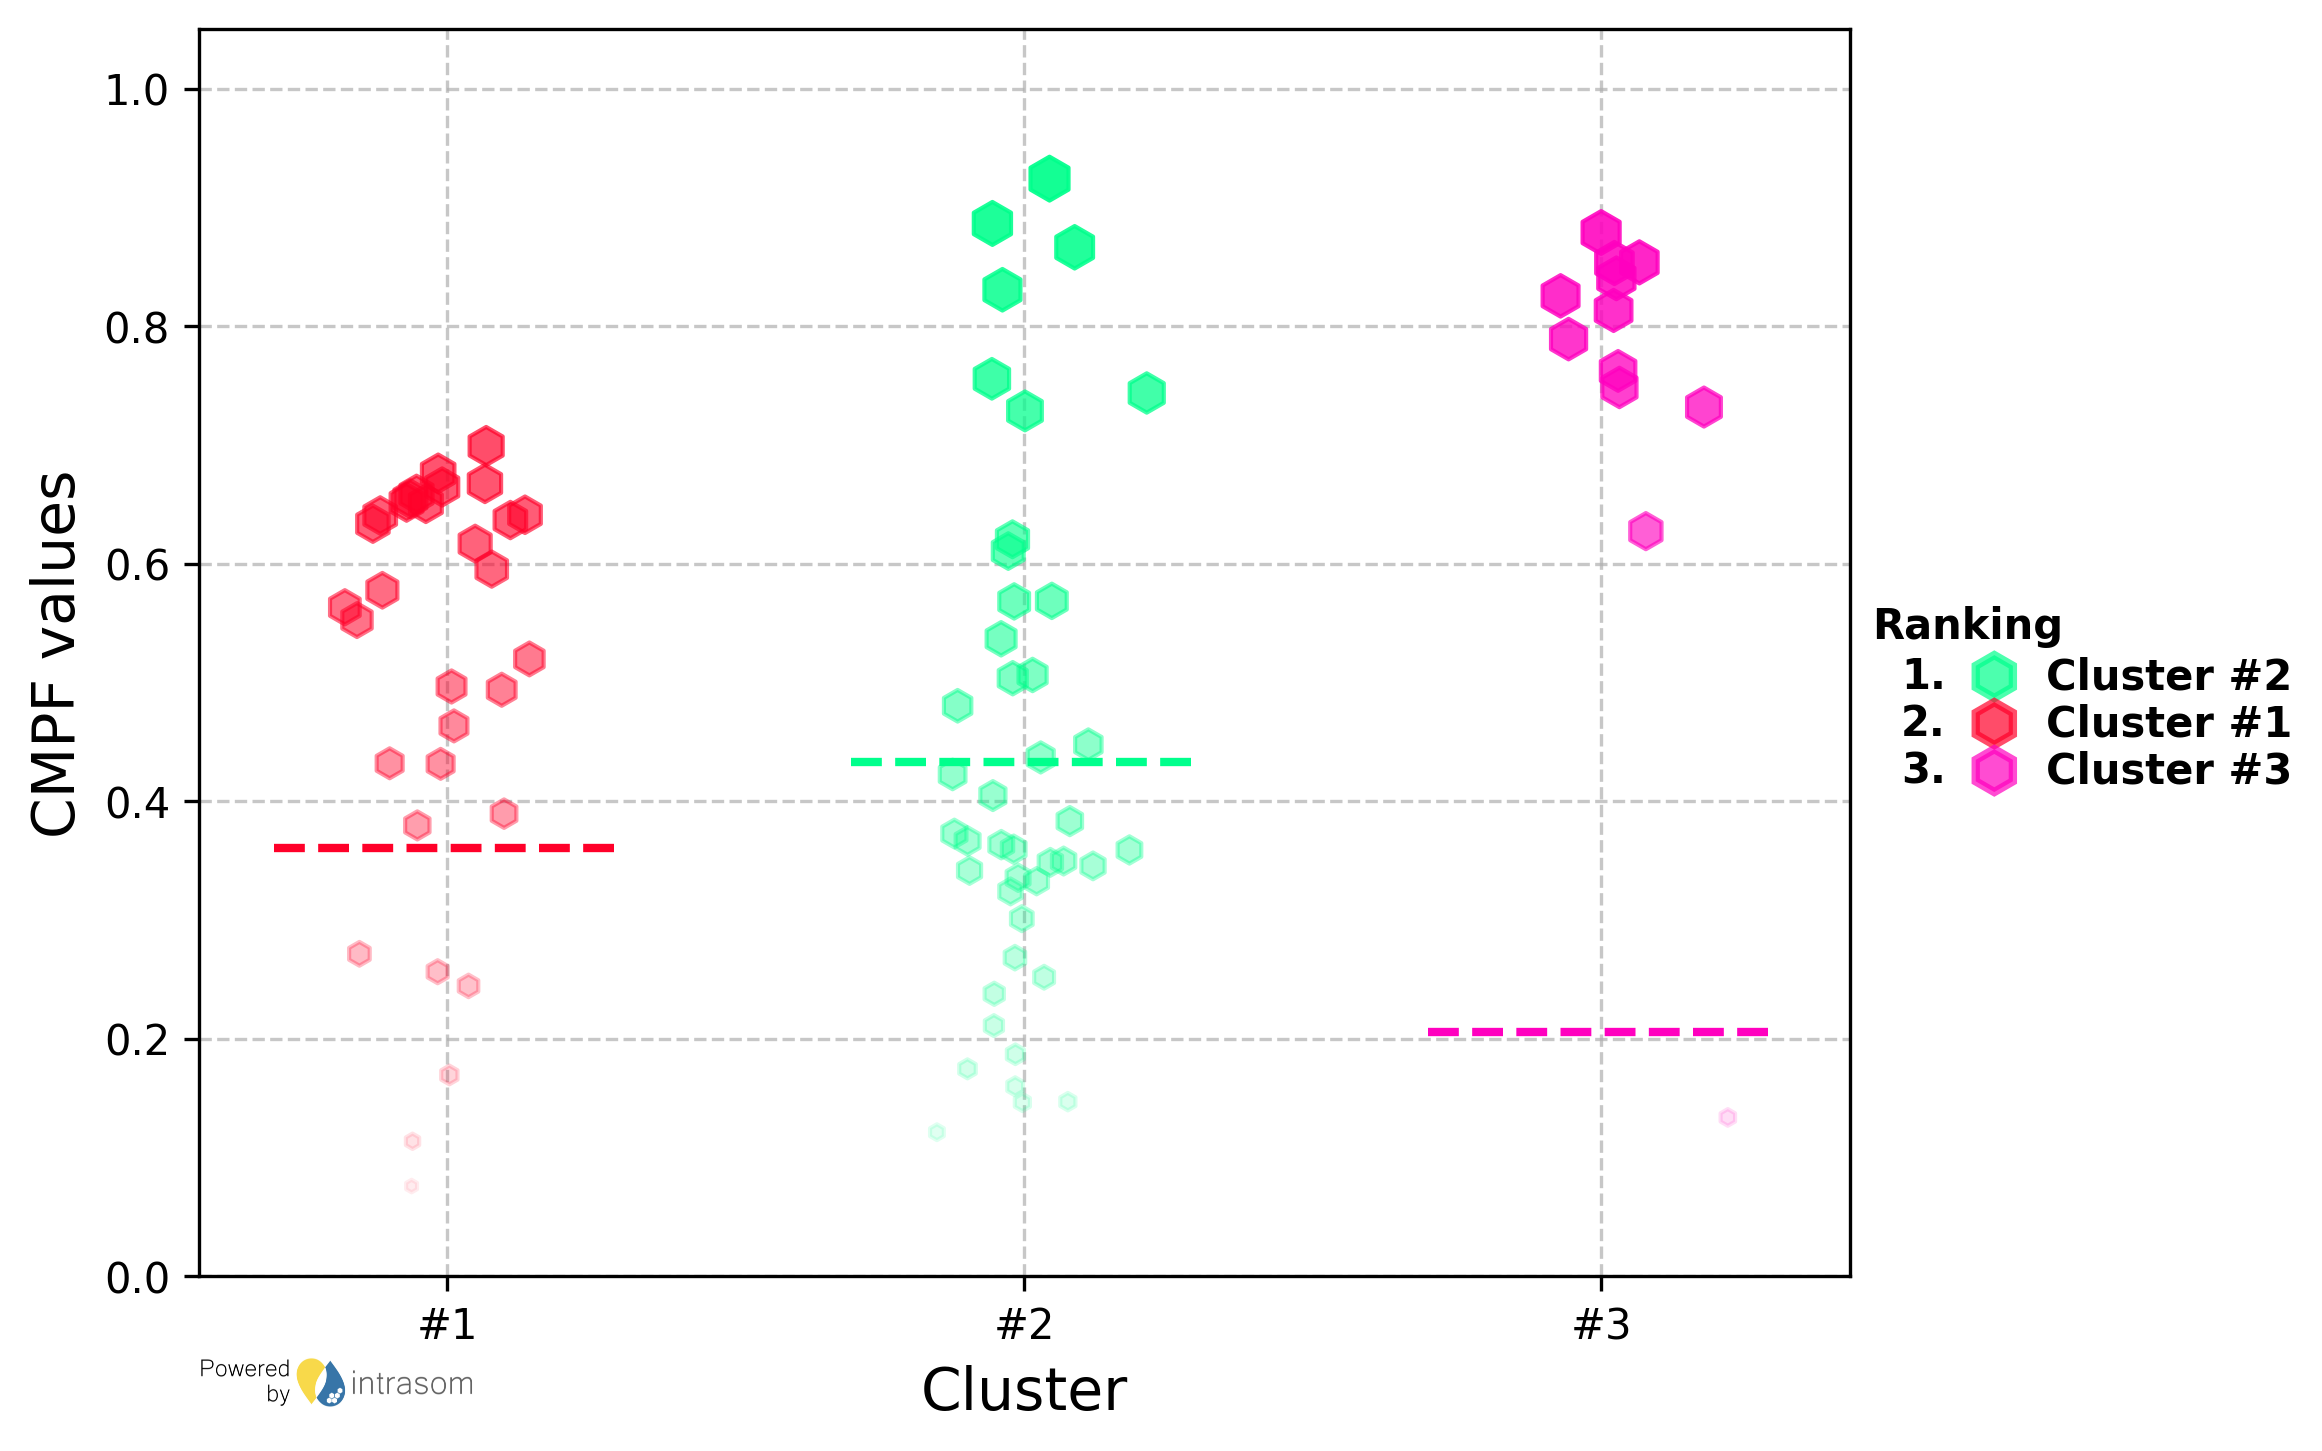

In [39]:
# It is possible to visualize the weights distribution in the jitterplot of the CMPF values of all neurons for each cluster
# Larger weights indicate that a cluster is close to a region with high concentration of neurons with more samples assigned to them, while smaller weights indicate that a cluster is isolated from these regions
representatives_iris.cmpf_jitter_plot(
    plot_width = 8,
    title = "",
    legend_title = "Ranking",
    yrange = [0.0,1.05],
    xlabel_size = 14,
    ylabel_size = 14,
    legend_title_size = 10,
    legend_text_size = 10,
    watermark_neurons = False)

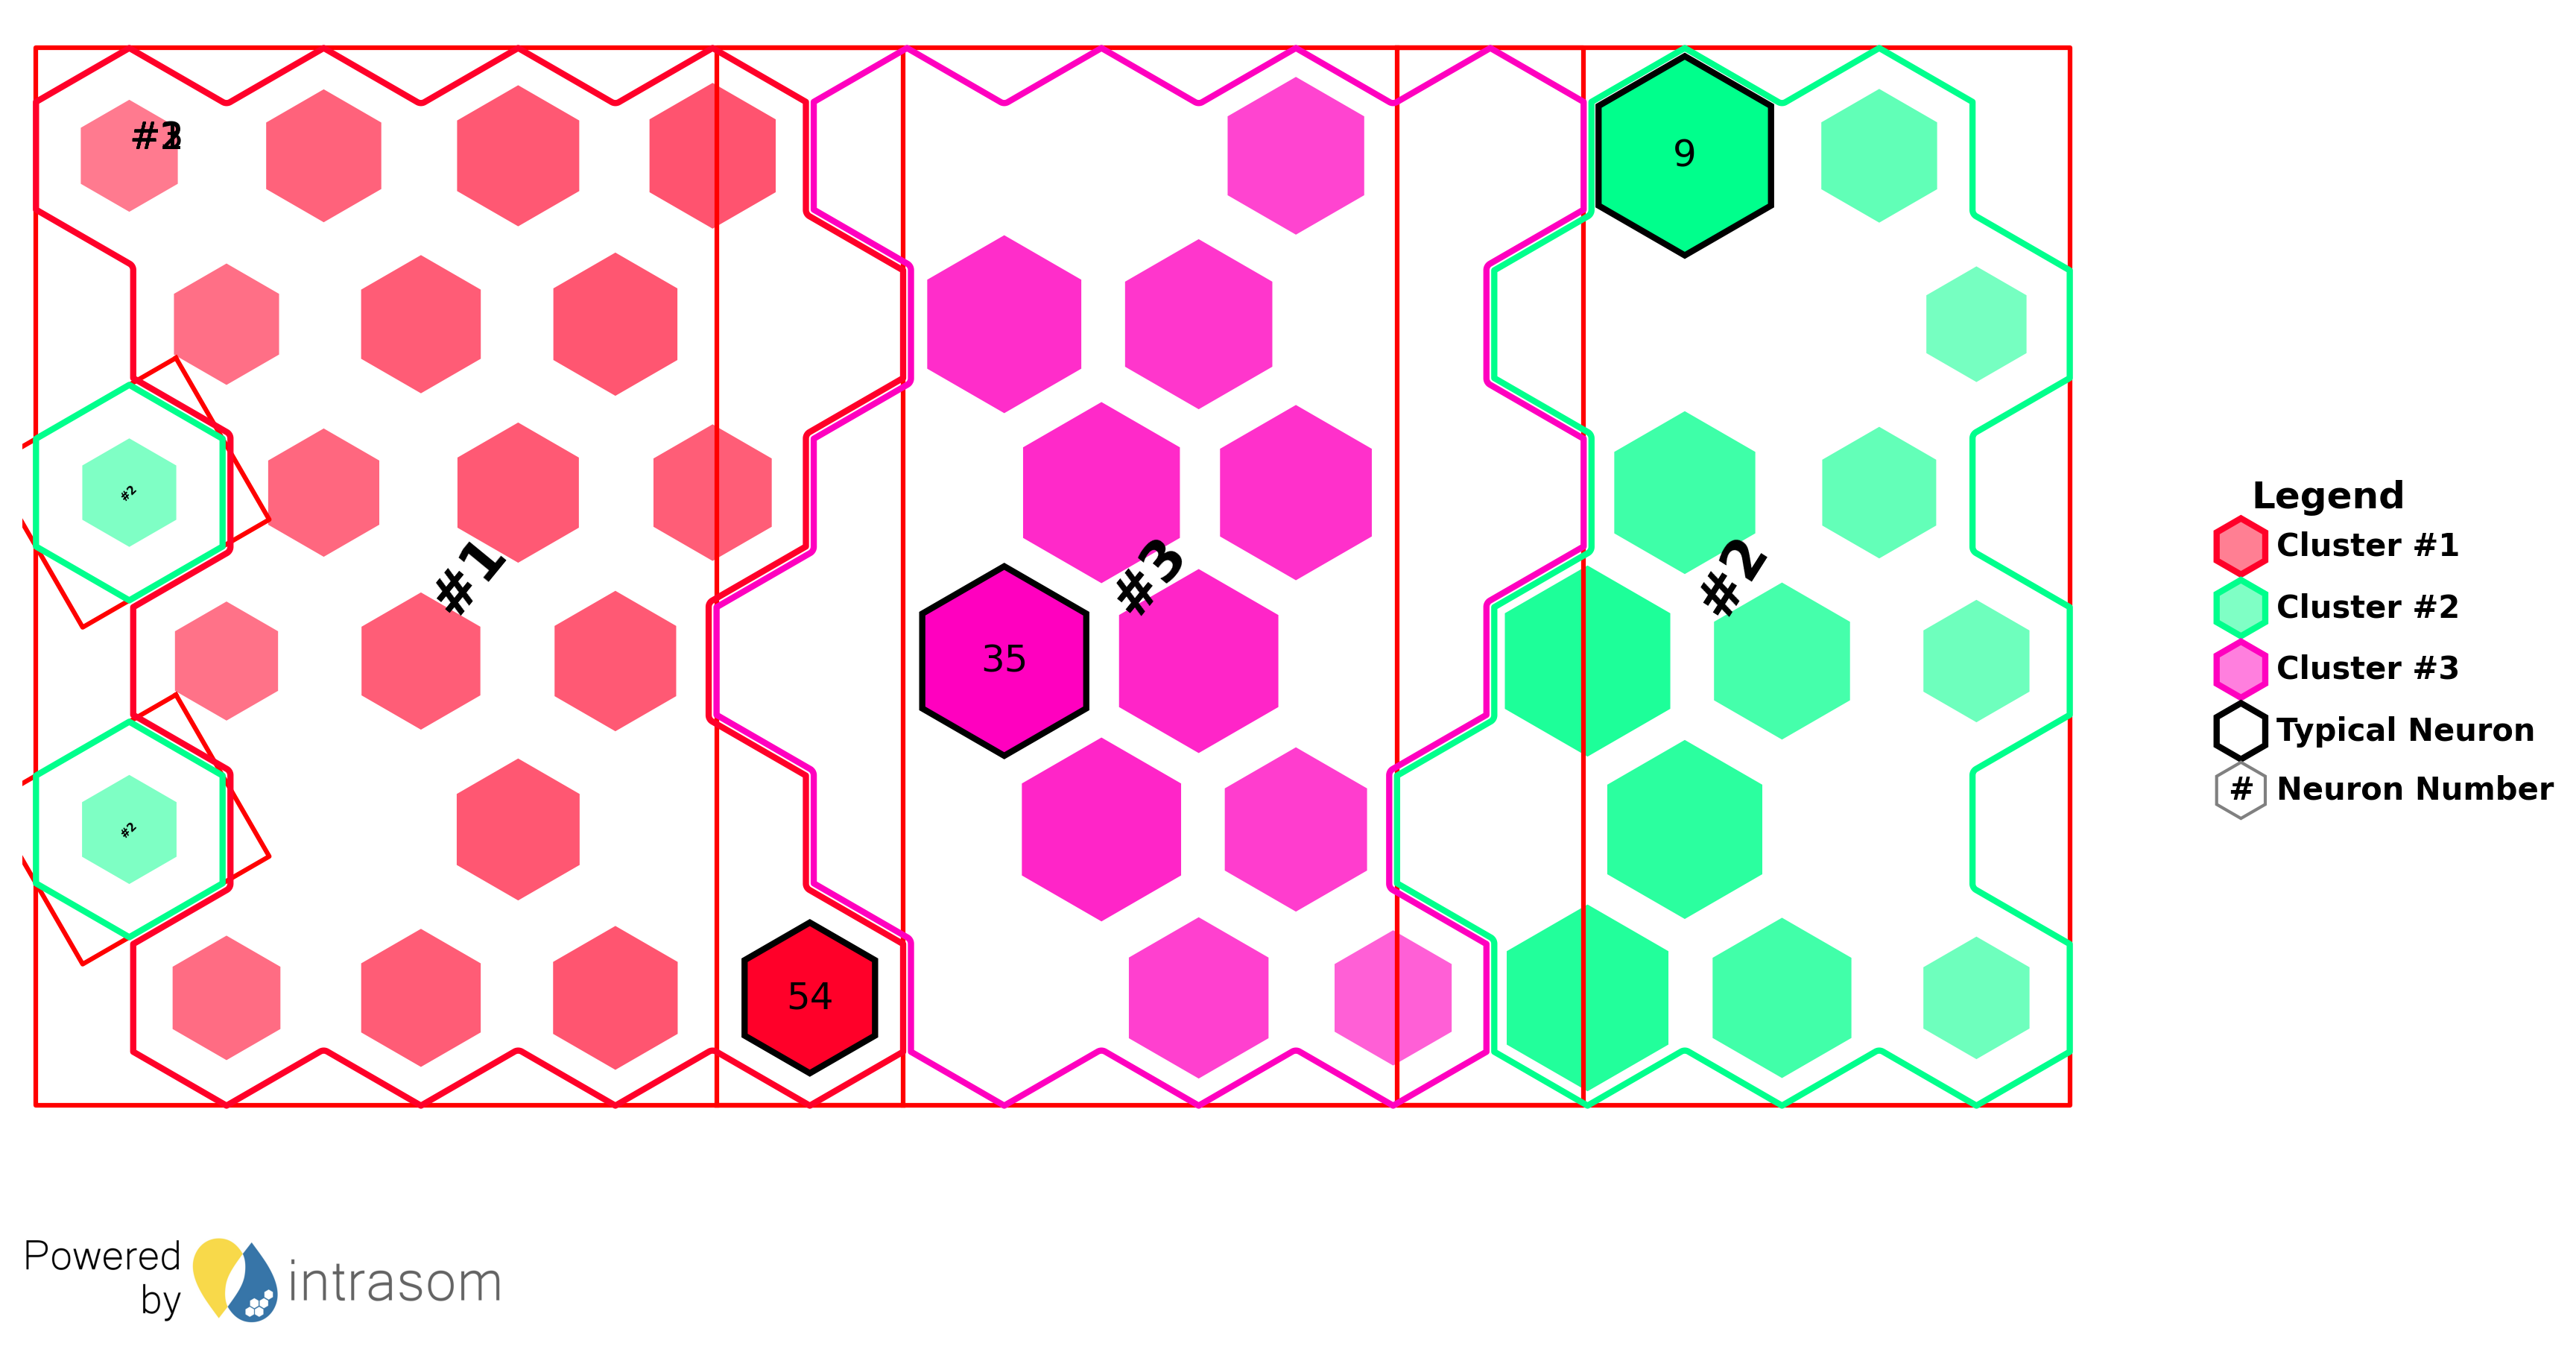

In [ ]:
# In the SOM space, we can verify these regions by plotting the maximum CMPF value of each neuron (improve this code)
representatives_iris.cmpf_som_plot(
    figsize = (14,8),
    watermark_neurons = False,
    watermark_typical_neurons = True,
    colormap = "gist_rainbow",
    title = "",
    plot_labels = True,
    auto_adjust_text = True,
    clusterout_maxtext_size = 12,
    alfa_clust_legend = 0.5,
    neuron_number_label = "Neuron Number",
    typical_neuron_label = "Typical Neuron")

In [ ]:
# Now, to select typical samples we can use different criteria obtained with the typical_sample_analysis method
typical_iris_analysis = representatives_iris.typical_sample_analysis()
typical_iris_analysis

,Sample_index,BMU,Cluster,CMPF_value,Silhouette,Samples_BMU_dists,Cluster_order
0,0,26,3,0.840185,0.732211,0.213190,3
1,1,7,3,0.731809,0.563684,0.304371,3
2,2,7,3,0.731809,0.674515,0.309147,3
3,3,7,3,0.731809,0.616640,0.247186,3
4,4,26,3,0.840185,0.726576,0.197945,3
...,...,...,...,...,...,...,...
145,145,2,1,0.616833,0.462843,0.413896,2
146,146,60,2,0.568609,0.202732,0.460828,1
147,147,12,1,0.641123,0.383029,0.218197,2
148,148,4,1,0.676040,0.379711,0.672048,2


In [ ]:
# These criteria are:
print(f'Samples with BMUs with highest CMPF values of each cluster: missing implementation.')
print(f'Samples with highest Silhouette Coefficient (SC) values of each cluster: {representatives_iris.sc_typical_samples_indices.values}')
print(f'Samples closest to the typical neuron of each cluster: {representatives_iris.cmpf_dists_typical_samples_indices.values}')

# Plot a PCA visualization comparing the three

Samples with BMUs with highest CMPF values of each cluster: missing implementation.
Samples with highest Silhouette Coefficient (SC) values of each cluster: [120  89   0]
Samples closest to the typical neuron of each cluster: [59 48 56]


In [ ]:
# Plot the Silhouette plot for the CMPF, SC (separating for each cluster) and Samples_BMU_dists (ordering by cluster then by BMU)

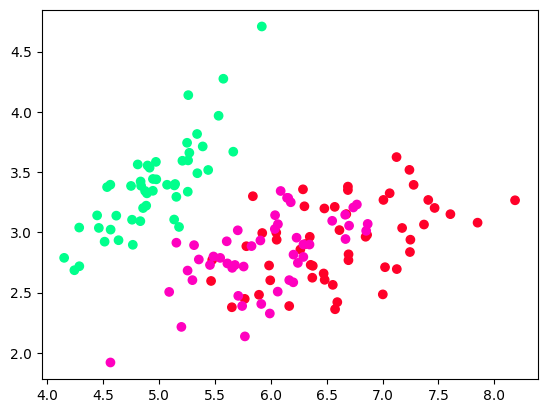

In [45]:
from sklearn.mixture import GaussianMixture
from matplotlib.patches import Ellipse

gmm = GaussianMixture(n_components=3, covariance_type='full', n_init=1, random_state=42)
gmm_labels = gmm.fit_predict(iris.data)
sampled_dataset = gmm.sample(n_samples=iris.data.shape[0])
data = sampled_dataset[0]
labels = sampled_dataset[1]
plt.scatter(data[:,0], data[:,1], c=labels, cmap='gist_rainbow')
plt.show()